In [3]:
import os
import random
from PIL import Image
import pandas as pd
from tqdm import tqdm
import os
import xml.etree.ElementTree as ET
from collections import defaultdict
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt


In [1]:
region="delhi_airshed"

Processing 8618735_3342435 with 28 objects...


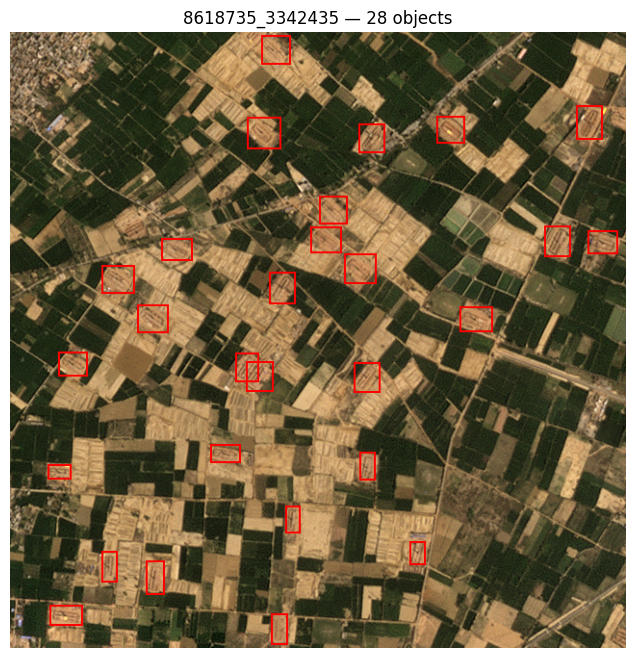

Processing 8621487_3345187 with 27 objects...


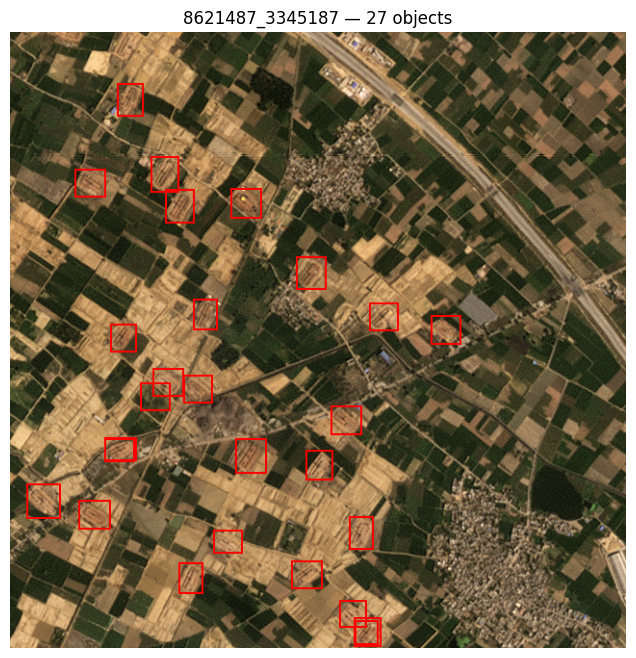

Processing 8615984_3279146 with 19 objects...


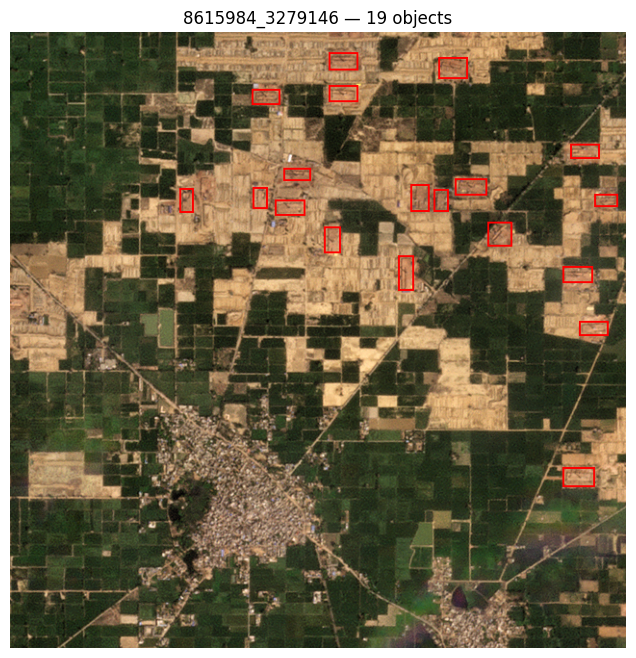

Processing 8560949_3367201 with 18 objects...


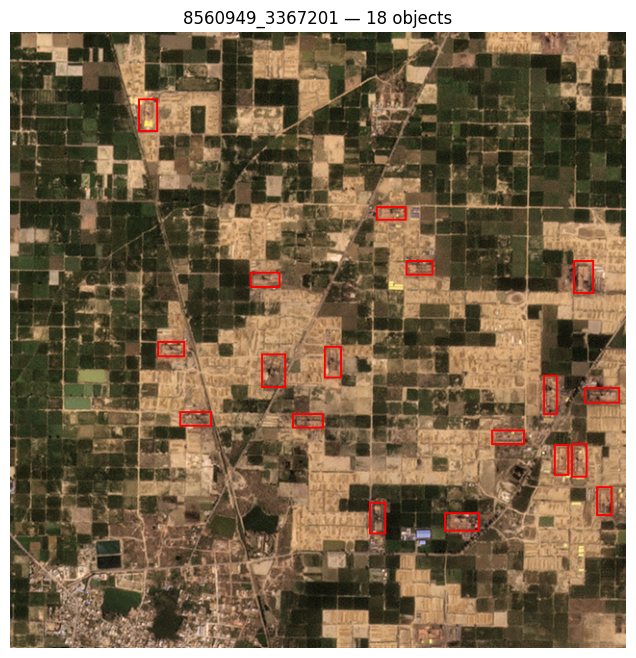

Processing 8563701_3350691 with 15 objects...


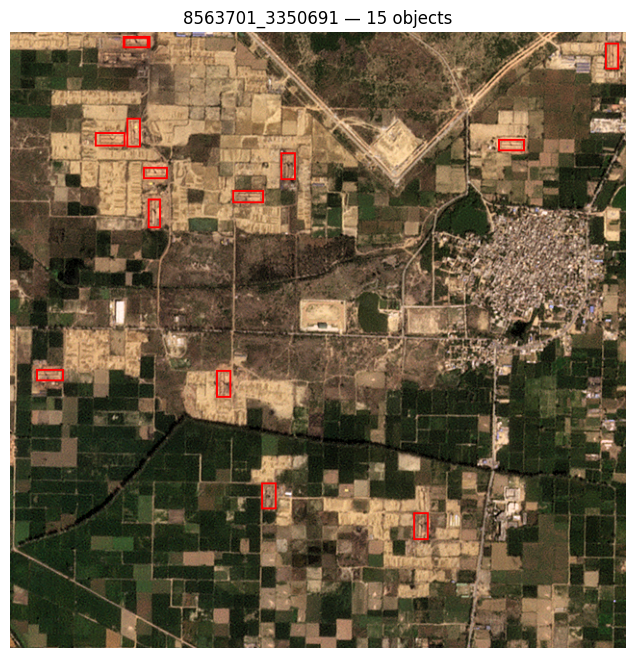

In [ ]:

# Paths
image_dir = f"../../data/processed_data/{region}/images"
label_dir_voc = f"../data/staclip/{region}/labels_voc"

# Step 1: Count objects in each annotation
image_object_counts = {}

for fname in os.listdir(label_dir_voc):
    if not fname.endswith('.txt'):
        continue
    txt_path = os.path.join(label_dir_voc, fname)
    with open(txt_path, 'r') as f:
        count = sum(1 for line in f if line.strip())
    image_id = os.path.splitext(fname)[0]
    image_object_counts[image_id] = count

# Step 2: Select top 5 by density
top5 = sorted(image_object_counts.items(), key=lambda x: x[1], reverse=True)[:5]

# Step 3: Plot the top 5 with bounding boxes
for image_id, count in top5:
    image_path = os.path.join(image_dir, f"{image_id}.tif")
    print(f"Processing {image_id} with {count} objects...")
    label_path = os.path.join(label_dir_voc, f"{image_id}.txt")

    # Load image
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)

    # Parse and draw bounding boxes from plain text file
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            _, x_min, y_min, x_max, y_max = parts
            x_min = int(float(x_min))
            y_min = int(float(y_min))
            x_max = int(float(x_max))
            y_max = int(float(y_max))
            draw.rectangle([x_min, y_min, x_max, y_max], outline="red", width=2)

    # Show image
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.title(f"{image_id} — {count} objects")
    plt.axis("off")
    plt.show()


In [ ]:


# --------- USER CONFIGURATION ---------
image_dir = f"/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data/staclip/{region}/images"
label_dir = f"/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data/staclip/{region}/labels_voc"
save_dir_pos = f"/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data/brick_kiln_crops/meso_patches/{region}_256x256_pos"
save_dir_neg = f"/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data/brick_kiln_crops/meso_patches/{region}_256x256_neg"
patch_size = 256

In [12]:


os.makedirs(save_dir_pos, exist_ok=True)
os.makedirs(save_dir_neg, exist_ok=True)

meta_pos, meta_neg = [], []
crop_id = 0

# ---- STEP 1: POSITIVE PATCHES ----
for fname in tqdm(os.listdir(label_dir)):
    if not fname.endswith(".txt"):
        continue
    image_id = os.path.splitext(fname)[0]
    image_path = os.path.join(image_dir, f"{image_id}.tif")
    label_path = os.path.join(label_dir, fname)
    if not os.path.exists(image_path):
        continue
    image = Image.open(image_path).convert("RGB")
    W, H = image.size
    with open(label_path, "r") as f:
        for i, line in enumerate(f):
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            _, x_min, y_min, x_max, y_max = map(float, parts)
            cx = int((x_min + x_max) / 2)
            cy = int((y_min + y_max) / 2)
            left = max(cx - patch_size // 2, 0)
            upper = max(cy - patch_size // 2, 0)
            right = min(left + patch_size, W)
            lower = min(upper + patch_size, H)
            patch = image.crop((left, upper, right, lower))
            patch_name = f"{image_id}_pos{i}_crop{crop_id}.png"
            patch.save(os.path.join(save_dir_pos, patch_name))
            meta_pos.append({"filename": patch_name, "cx": cx, "cy": cy, "label": 1})
            crop_id += 1

# ---- STEP 2: NEGATIVE PATCHES ----
# Find images with NO labels (negative context)
labeled_images = set([os.path.splitext(f)[0] for f in os.listdir(label_dir) if f.endswith(".txt")])
all_images = set([os.path.splitext(f)[0] for f in os.listdir(image_dir) if f.endswith(".tif")])
unlabeled_images = list(all_images - labeled_images)

for image_id in tqdm(unlabeled_images):
    image_path = os.path.join(image_dir, f"{image_id}.tif")
    image = Image.open(image_path).convert("RGB")
    W, H = image.size
    for i in range(3):  # number of negatives per image
        cx = random.randint(patch_size // 2, W - patch_size // 2)
        cy = random.randint(patch_size // 2, H - patch_size // 2)
        left = cx - patch_size // 2
        upper = cy - patch_size // 2
        right = left + patch_size
        lower = upper + patch_size
        patch = image.crop((left, upper, right, lower))
        patch_name = f"{image_id}_neg{i}_crop{crop_id}.png"
        patch.save(os.path.join(save_dir_neg, patch_name))
        meta_neg.append({"filename": patch_name, "cx": cx, "cy": cy, "label": 0})
        crop_id += 1

# ---- STEP 3: Save Patch Metadata ----
df_pos = pd.DataFrame(meta_pos)
df_neg = pd.DataFrame(meta_neg)
df_meta = pd.concat([df_pos, df_neg], ignore_index=True)
df_meta.to_csv("delhi_meso_patch_metadata.csv", index=False)


  0%|          | 0/196 [00:00<?, ?it/s]

100%|██████████| 920/920 [00:39<00:00, 23.21it/s]


In [4]:

region="lucknow_airshed"
# --------- USER CONFIGURATION ---------
image_dir = f"/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data/staclip/{region}/images"
label_dir = f"/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data/staclip/{region}/labels_voc"

In [5]:
save_dir = "../data/brick_kiln_crops/meso_patches/lucknow_airshed_256x256_unlabeled"  # e.g., "../data/brick_kiln_crops/meso_patches/lucknow_256x256_unlabeled"
patch_size = 256
stride = 128  # Overlap = 50%

os.makedirs(save_dir, exist_ok=True)
meta = []
crop_id = 0

for fname in tqdm(os.listdir(image_dir)):
    if not fname.endswith(".tif"):
        continue
    image_id = os.path.splitext(fname)[0]
    image_path = os.path.join(image_dir, fname)
    image = Image.open(image_path).convert("RGB")
    W, H = image.size

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            patch = image.crop((x, y, x + patch_size, y + patch_size))
            patch_name = f"{image_id}_x{x}_y{y}_crop{crop_id}.png"
            patch.save(os.path.join(save_dir, patch_name))
            meta.append({"filename": patch_name, "x": x, "y": y, "image_id": image_id})
            crop_id += 1

# Save metadata for downstream analysis
df_meta = pd.DataFrame(meta)
df_meta.to_csv("lucknow_meso_patch_metadata.csv", index=False)


100%|██████████| 598/598 [01:49<00:00,  5.45it/s]


In [6]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn as nn
import torch.optim as optim

# --- 1. Dataset ---
class MesoPatchDataset(Dataset):
    def __init__(self, pos_dir, neg_dir, transform):
        self.samples = []
        self.transform = transform
        # Positive
        for f in os.listdir(pos_dir):
            if f.endswith('.png'):
                self.samples.append((os.path.join(pos_dir, f), 1))
        # Negative
        for f in os.listdir(neg_dir):
            if f.endswith('.png'):
                self.samples.append((os.path.join(neg_dir, f), 0))
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        return self.transform(img), label

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

pos_dir = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data/brick_kiln_crops/meso_patches/delhi_airshed_256x256_pos"
neg_dir = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data/brick_kiln_crops/meso_patches/delhi_airshed_256x256_neg"
dataset = MesoPatchDataset(pos_dir, neg_dir, transform)
loader = DataLoader(dataset, batch_size=512, shuffle=True, num_workers=4)

# --- 2. Model ---
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
model = models.resnet50(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

# --- 3. Train ---
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()
for epoch in tqdm(range(30)):  # Adjust as needed
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch}: Loss {total_loss / len(loader):.4f}")

torch.save(model.state_dict(), "meso_resnet50_classifier.pth")


/opt/anaconda3/envs/rishabh_sat/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/rishabh_sat/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
  3%|▎         | 1/30 [00:06<03:08,  6.50s/it]

Epoch 0: Loss 0.4258


  7%|▋         | 2/30 [00:12<02:55,  6.26s/it]

Epoch 1: Loss 0.0392


 10%|█         | 3/30 [00:18<02:50,  6.31s/it]

...

Epoch 27: Loss 0.0002


 97%|█████████▋| 29/30 [03:00<00:06,  6.29s/it]

Epoch 28: Loss 0.0001


100%|██████████| 30/30 [03:06<00:00,  6.22s/it]

Epoch 29: Loss 0.0001


In [7]:
# Remove classifier head for embedding extraction
model.fc = nn.Identity()
model.eval()

def extract_embeddings(image_dir, save_path):
    embeddings = []
    filenames = []
    for fname in os.listdir(image_dir):
        if not fname.endswith(".png"):
            continue
        img = Image.open(os.path.join(image_dir, fname)).convert("RGB")
        x = transform(img).unsqueeze(0).to(device)
        with torch.no_grad():
            emb = model(x).squeeze().cpu()
        embeddings.append(emb)
        filenames.append(fname)
    embeddings = torch.stack(embeddings)
    torch.save({"embeddings": embeddings, "filenames": filenames}, save_path)
    print(f"Saved: {save_path}")

# Delhi: positive and negative
extract_embeddings(pos_dir, "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/an_embedding_active_learning/embedding_meso/meso_embeddings_delhi_pos.pt")
extract_embeddings(neg_dir, "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/an_embedding_active_learning/embedding_meso/meso_embeddings_delhi_neg.pt")

# Lucknow: unlabeled
unl_dir = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data/brick_kiln_crops/meso_patches/lucknow_airshed_256x256_unlabeled"
extract_embeddings(unl_dir, "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/an_embedding_active_learning/embedding_meso/meso_embeddings_lucknow_unl.pt")


Saved: /home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/an_embedding_active_learning/embedding_meso/meso_embeddings_delhi_pos.pt
Saved: /home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/an_embedding_active_learning/embedding_meso/meso_embeddings_delhi_neg.pt
Saved: /home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/an_embedding_active_learning/embedding_meso/meso_embeddings_lucknow_unl.pt


In [11]:
import torch

# Update these paths as needed
emb_pos = torch.load("./embedding_meso/meso_embeddings_delhi_pos.pt")  # dict with 'embeddings', 'filenames'
emb_neg = torch.load("./embedding_meso/meso_embeddings_delhi_neg.pt")
emb_unl = torch.load("./embedding_meso/meso_embeddings_lucknow_unl.pt")

labeled_meso_emb = torch.cat([emb_pos["embeddings"], emb_neg["embeddings"]], dim=0)  # (P+N, D)
labeled_meso_fnames = emb_pos["filenames"] + emb_neg["filenames"]
unlabeled_meso_emb = emb_unl["embeddings"]  # (U, D)
unlabeled_meso_fnames = emb_unl["filenames"]


In [9]:
import torch
import ot
from sklearn.decomposition import PCA
from scipy.stats import wasserstein_distance

# ---- 1. Cosine similarities ----
labeled_norm = torch.nn.functional.normalize(labeled_meso_emb, dim=1)
unlabeled_norm = torch.nn.functional.normalize(unlabeled_meso_emb, dim=1)
similarity = torch.matmul(unlabeled_norm, labeled_norm.T)  # (U, L)

# ---- 2. Max similarity (uncertainty = 1 - max) ----
max_sim, _ = torch.max(similarity, dim=1)
uncertainty_max = 1 - max_sim

# ---- 3. Top-k similarity (uncertainty = 1 - mean of top k) ----
topk_vals, _ = torch.topk(similarity, k=5, dim=1)
avg_topk_sim = topk_vals.mean(dim=1)
uncertainty_topk = 1 - avg_topk_sim

# ---- 4. Entropy (softmax over similarities) ----
probs = torch.nn.functional.softmax(similarity, dim=1)
entropy = -torch.sum(probs * torch.log(probs + 1e-10), dim=1)

# ---- 5. GCNU (1-max_sim) * (1/local density in unlabeled set) ----
local_sim = torch.matmul(unlabeled_norm, unlabeled_norm.T)
_, top10_local = torch.topk(local_sim, k=11, dim=1)  # includes self
local_density = torch.stack([
    local_sim[i, idx[1:]].mean() for i, idx in enumerate(top10_local)
])
uncertainty_gcnu = (1 - max_sim) * (1 / (local_density + 1e-6))

# ---- 6. MMD per patch (RBF kernel, labeled vs each patch) ----
def rbf_kernel(x, y, sigma=5.0):
    dist = torch.cdist(x, y)
    return torch.exp(-dist ** 2 / (2 * sigma ** 2))

def mmd_single_patch(u, ref_bank, sigma=5.0):
    K_uu = 1  # self-similarity for singleton
    K_rr = rbf_kernel(ref_bank, ref_bank, sigma).mean()
    K_ur = rbf_kernel(u, ref_bank, sigma).mean()
    return K_uu + K_rr - 2 * K_ur

sigma = 5.0
mmd_uncertainty = []
for i in range(unlabeled_meso_emb.shape[0]):
    u = unlabeled_meso_emb[i:i+1]
    score = mmd_single_patch(u, labeled_meso_emb, sigma=sigma)
    mmd_uncertainty.append(score)
mmd_uncertainty = torch.tensor(mmd_uncertainty)

# ---- 7. Wasserstein (high-dimensional, patchwise via POT) ----
Xs = labeled_meso_emb.cpu().numpy()
Xt = unlabeled_meso_emb.cpu().numpy()
a = torch.ones(Xs.shape[0]) / Xs.shape[0]
a = a.numpy()
uncertainty_wasserstein = []
for i in range(Xt.shape[0]):
    mi = ot.dist(Xt[i:i+1], Xs)
    wi = ot.emd2([1.0], a, mi)
    uncertainty_wasserstein.append(wi)
uncertainty_wasserstein = torch.tensor(uncertainty_wasserstein)

# ---- 8. Wasserstein (PCA aggregate, 10 components) ----
n_components = 10
all_emb = torch.cat([labeled_meso_emb, unlabeled_meso_emb], dim=0).cpu().numpy()
pca = PCA(n_components=n_components, random_state=42)
pca.fit(all_emb)
Xs_proj = pca.transform(labeled_meso_emb.cpu().numpy())
Xt_proj = pca.transform(unlabeled_meso_emb.cpu().numpy())
uncertainty_wasserstein_pca = []
for i in range(Xt_proj.shape[0]):
    wscores = [
        wasserstein_distance([Xt_proj[i, j]], Xs_proj[:, j]) 
        for j in range(n_components)
    ]
    uncertainty_wasserstein_pca.append(sum(wscores)/len(wscores))
uncertainty_wasserstein_pca = torch.tensor(uncertainty_wasserstein_pca)

# ---- 9. Save all uncertainties ----
uncertainty_dict = {
    "filenames": unlabeled_meso_fnames,
    "uncertainty_max": uncertainty_max.cpu().numpy().tolist(),
    "uncertainty_topk": uncertainty_topk.cpu().numpy().tolist(),
    "uncertainty_entropy": entropy.cpu().numpy().tolist(),
    "uncertainty_gcnu": uncertainty_gcnu.cpu().numpy().tolist(),
    "uncertainty_mmd": mmd_uncertainty.cpu().numpy().tolist(),
    "uncertainty_wasserstein": uncertainty_wasserstein.cpu().numpy().tolist(),
    "uncertainty_wasserstein_pca": uncertainty_wasserstein_pca.cpu().numpy().tolist(),
}
torch.save(uncertainty_dict, "meso_uncertainty_scores.pt")


2025-07-13 21:54:56.640743: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752423896.667742 2706429 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752423896.675978 2706429 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752423896.708679 2706429 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752423896.708699 2706429 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752423896.708702 2706429 computation_placer.cc:177] computation placer alr

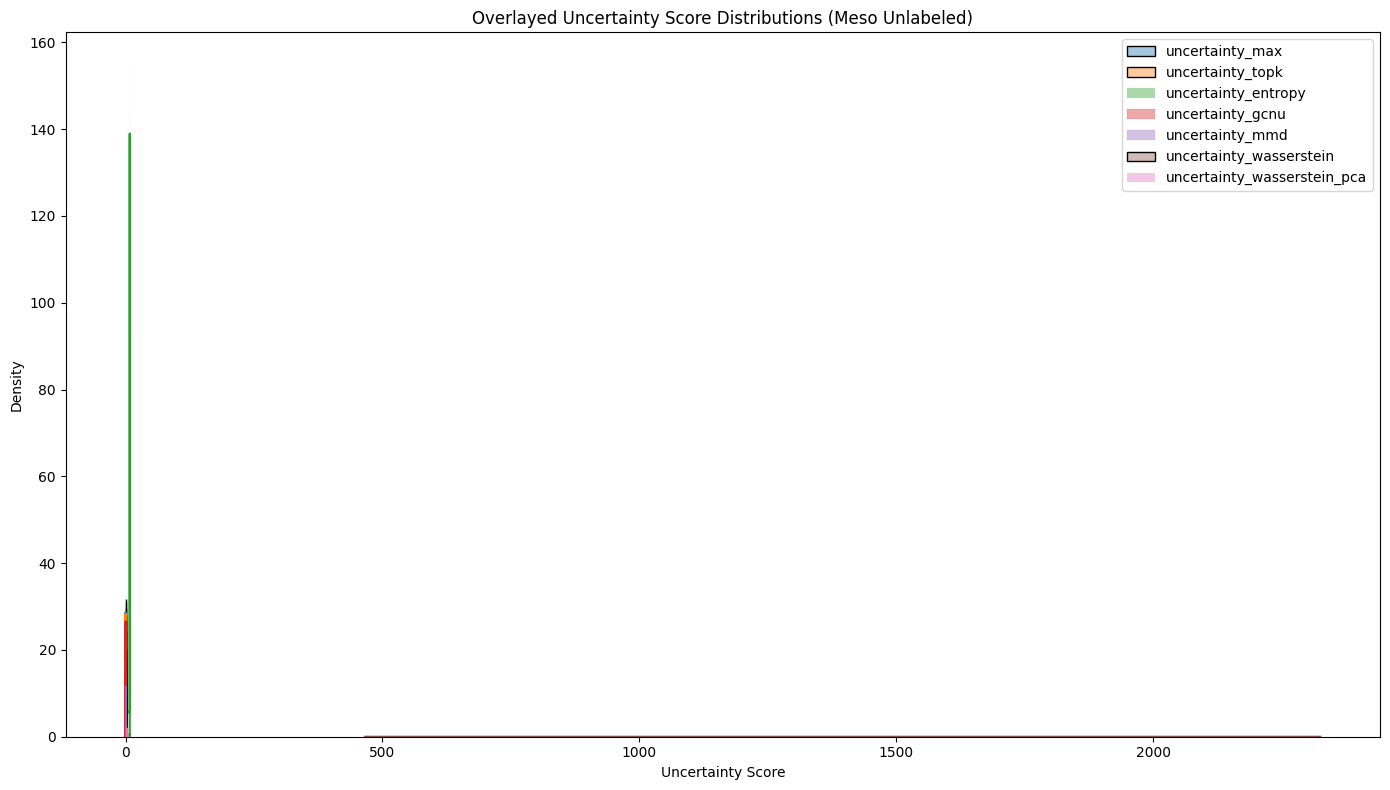

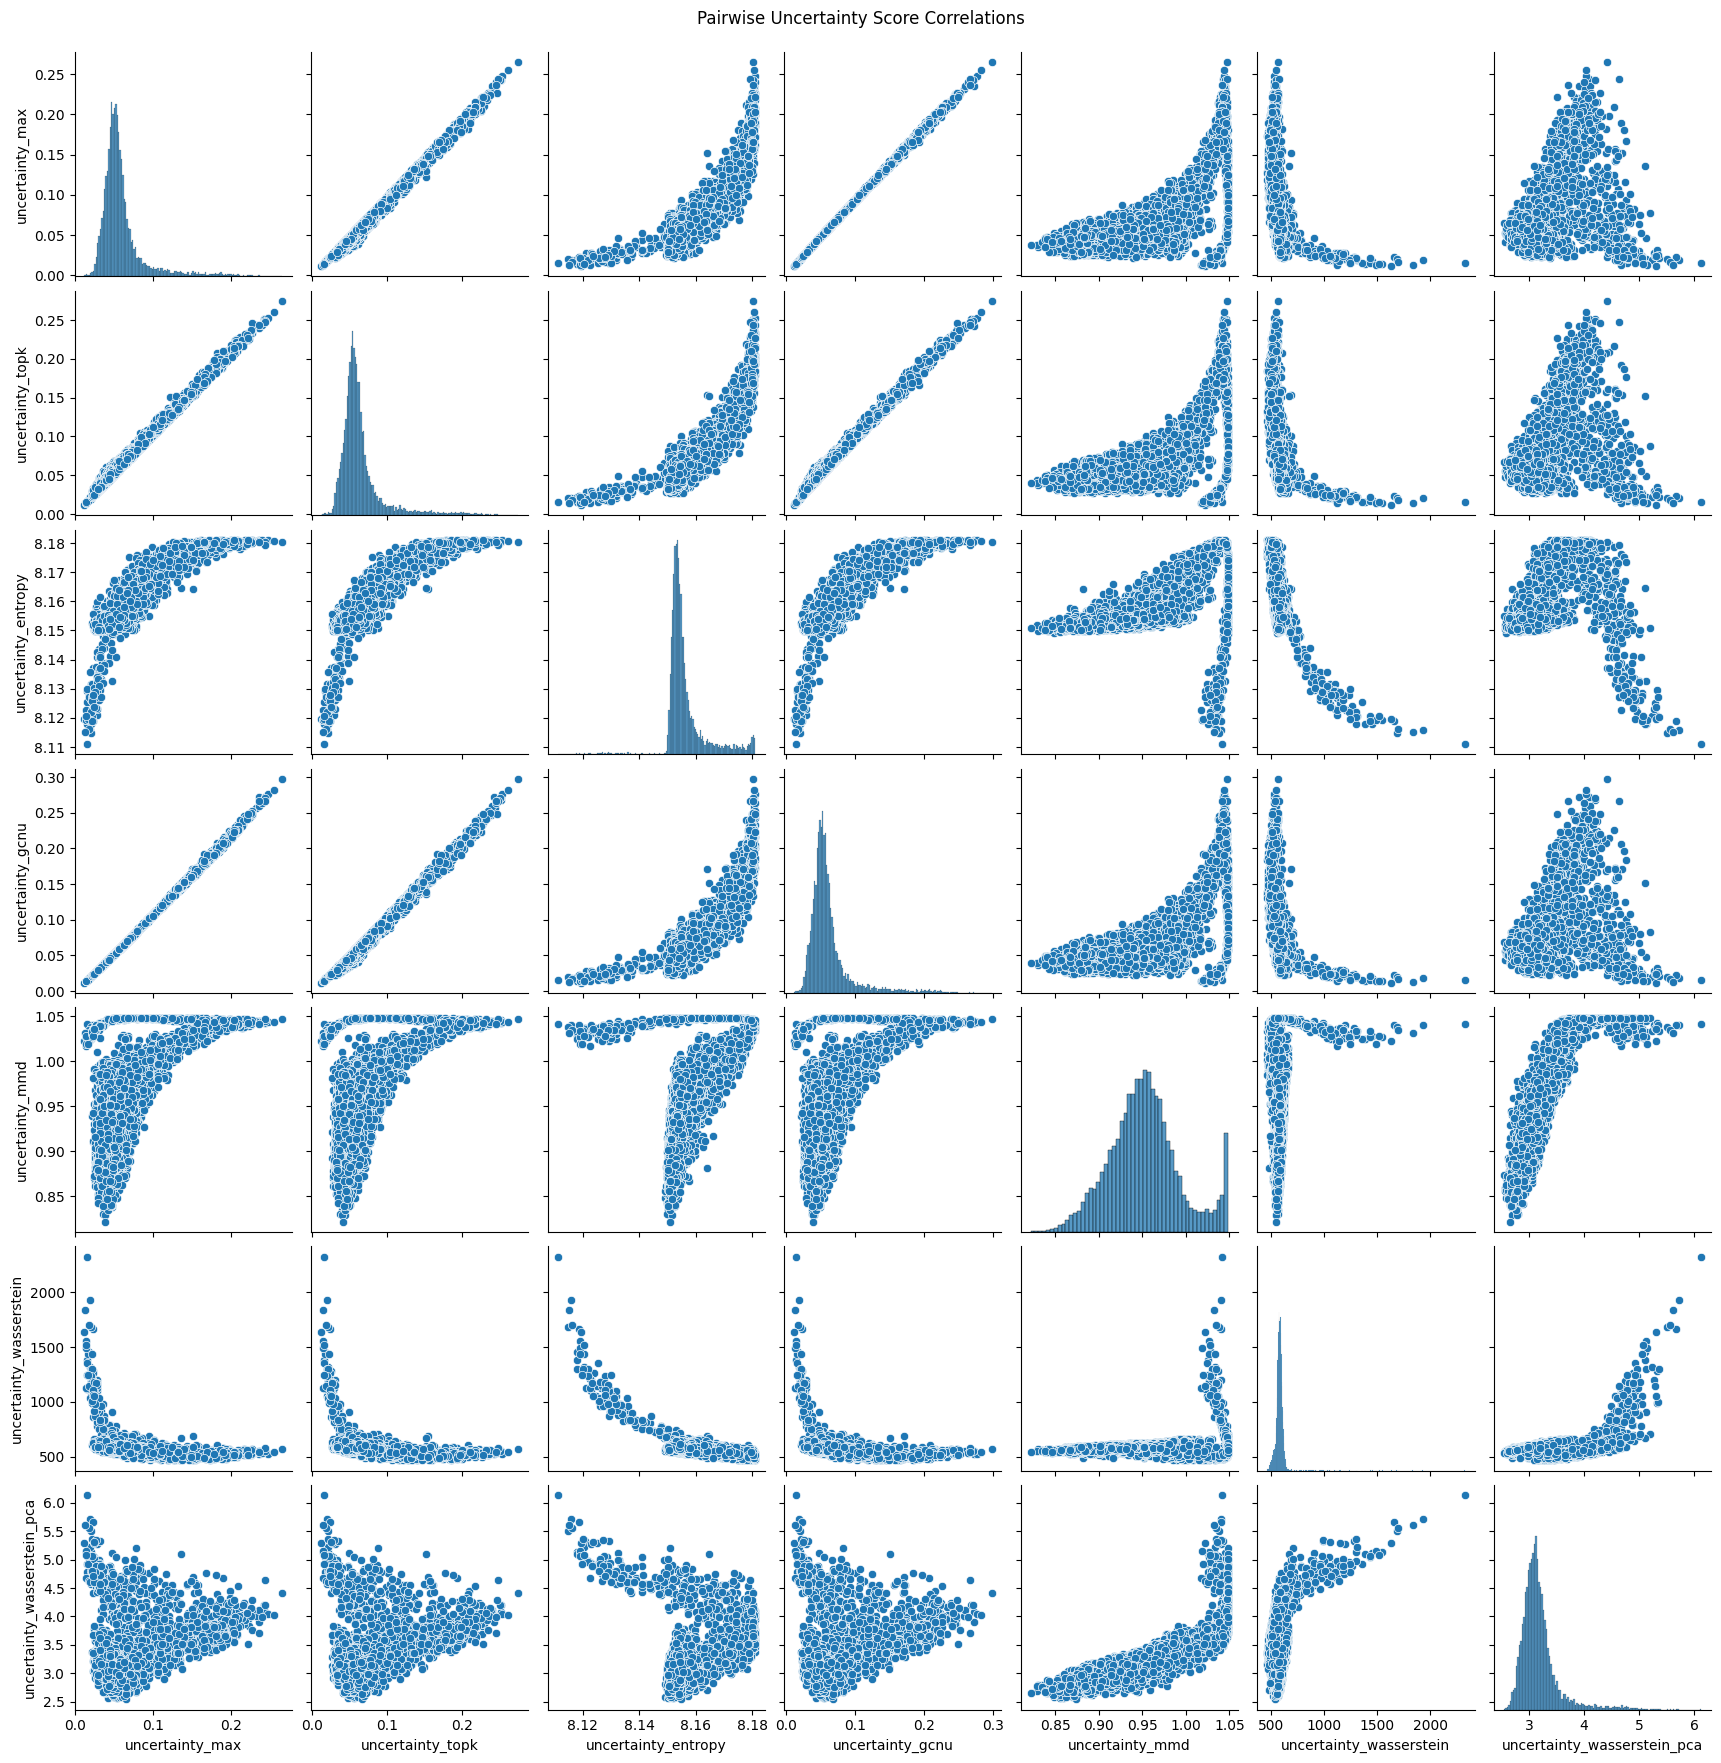

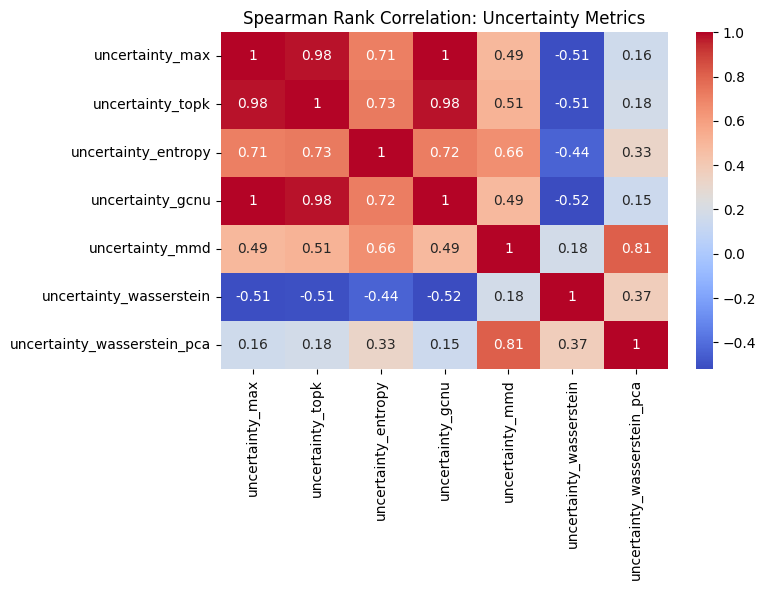

Spearman correlation between uncertainty_max and uncertainty_topk: 0.9783, p-value: 0.0000e+00
Spearman correlation between uncertainty_max and uncertainty_entropy: 0.7113, p-value: 0.0000e+00
Spearman correlation between uncertainty_max and uncertainty_gcnu: 0.9997, p-value: 0.0000e+00
Spearman correlation between uncertainty_max and uncertainty_mmd: 0.4896, p-value: 0.0000e+00
Spearman correlation between uncertainty_max and uncertainty_wasserstein: -0.5129, p-value: 0.0000e+00
Spearman correlation between uncertainty_max and uncertainty_wasserstein_pca: 0.1574, p-value: 3.7671e-54
Spearman correlation between uncertainty_topk and uncertainty_max: 0.9783, p-value: 0.0000e+00
Spearman correlation between uncertainty_topk and uncertainty_entropy: 0.7290, p-value: 0.0000e+00
Spearman correlation between uncertainty_topk and uncertainty_gcnu: 0.9787, p-value: 0.0000e+00
Spearman correlation between uncertainty_topk and uncertainty_mmd: 0.5149, p-value: 0.0000e+00
Spearman correlation bet

In [10]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import spearmanr

# ---- Load your uncertainty dict ----
uncertainty_dict = torch.load("meso_uncertainty_scores.pt")
df = pd.DataFrame(uncertainty_dict)

# --- 1. Overlayed histogram for all scores ---
plt.figure(figsize=(14, 8))
for col in [
    "uncertainty_max",
    "uncertainty_topk",
    "uncertainty_entropy",
    "uncertainty_gcnu",
    "uncertainty_mmd",
    "uncertainty_wasserstein",
    "uncertainty_wasserstein_pca"
]:
    sns.histplot(df[col], bins=50, kde=True, stat="density", label=col, alpha=0.4)
plt.legend()
plt.title("Overlayed Uncertainty Score Distributions (Meso Unlabeled)")
plt.xlabel("Uncertainty Score")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

# --- 2. Pairwise scatterplots (correlations) ---
sns.pairplot(df[[
    "uncertainty_max",
    "uncertainty_topk",
    "uncertainty_entropy",
    "uncertainty_gcnu",
    "uncertainty_mmd",
    "uncertainty_wasserstein",
    "uncertainty_wasserstein_pca"
]])
plt.suptitle("Pairwise Uncertainty Score Correlations", y=1.01)
plt.show()

# --- 3. (Optional) Rank correlation heatmap ---
corrs = df[[
    "uncertainty_max",
    "uncertainty_topk",
    "uncertainty_entropy",
    "uncertainty_gcnu",
    "uncertainty_mmd",
    "uncertainty_wasserstein",
    "uncertainty_wasserstein_pca"
]].corr(method='spearman')
plt.figure(figsize=(8,6))
sns.heatmap(corrs, annot=True, cmap="coolwarm")
plt.title("Spearman Rank Correlation: Uncertainty Metrics")
plt.tight_layout()
plt.show()
# --- 4. Spearman correlation coefficients ---
spearman_results = {}
for col1 in df.columns[1:]:
    for col2 in df.columns[1:]:
        if col1 != col2:
            corr, pval = spearmanr(df[col1], df[col2])
            spearman_results[(col1, col2)] = (corr, pval)
# Print Spearman results
for (col1, col2), (corr, pval) in spearman_results.items():
    print(f"Spearman correlation between {col1} and {col2}: {corr:.4f}, p-value: {pval:.4e}")
# Save the DataFrame for further analysis
df.to_csv("meso_uncertainty_scores.csv", index=False)